In [1]:
from orbitx import TLE
import numpy as np
tle = TLE.from_sat_shortname("S6", np.datetime64("2020-02-01T00:00:00"), np.datetime64("2020-02-01T12:00:00"))
print(tle)

C:\Users\xl3\Documents\projects\orbitx\orbitx\utils\_tle\filter_xarray.py:48: UserWarning: The oldest TLE file is more recent than the start time requested.
Oldest TLE file: 2020-02-01T00:00:00
Start time requested: 2020-02-01T00:00:00
  warnings.warn(



TLE object for the satellite Sentinel-6 with short name S6.
Satellite catalog number: 46984.
Satellite classification: Unclassified.
Launch year: 2020.
Launch number: 87.
Launch piece: A.
Number of TLEs included: 1.
Reference date for dates in 'senconds since reference date': 1970-01-01T00:00:00.
Start date for the orbit to simulate: 2020-02-01T00:00:00.
End date for the orbit to simulate: 2020-02-01T12:00:00.



In [2]:
from orbitx import Orbit
import numpy as np


Orbit object for satellites ['S6', 'SA'].
Start date: 2020-02-01T00:00:00
End date: 2020-02-01T12:00:00
Propagation sampling interval: 20 seconds
Interpolation sampling interval: 5 seconds
Reference date used to represent time in seconds since: 2000-01-01T00:00:00
Number of simulated times: 8641


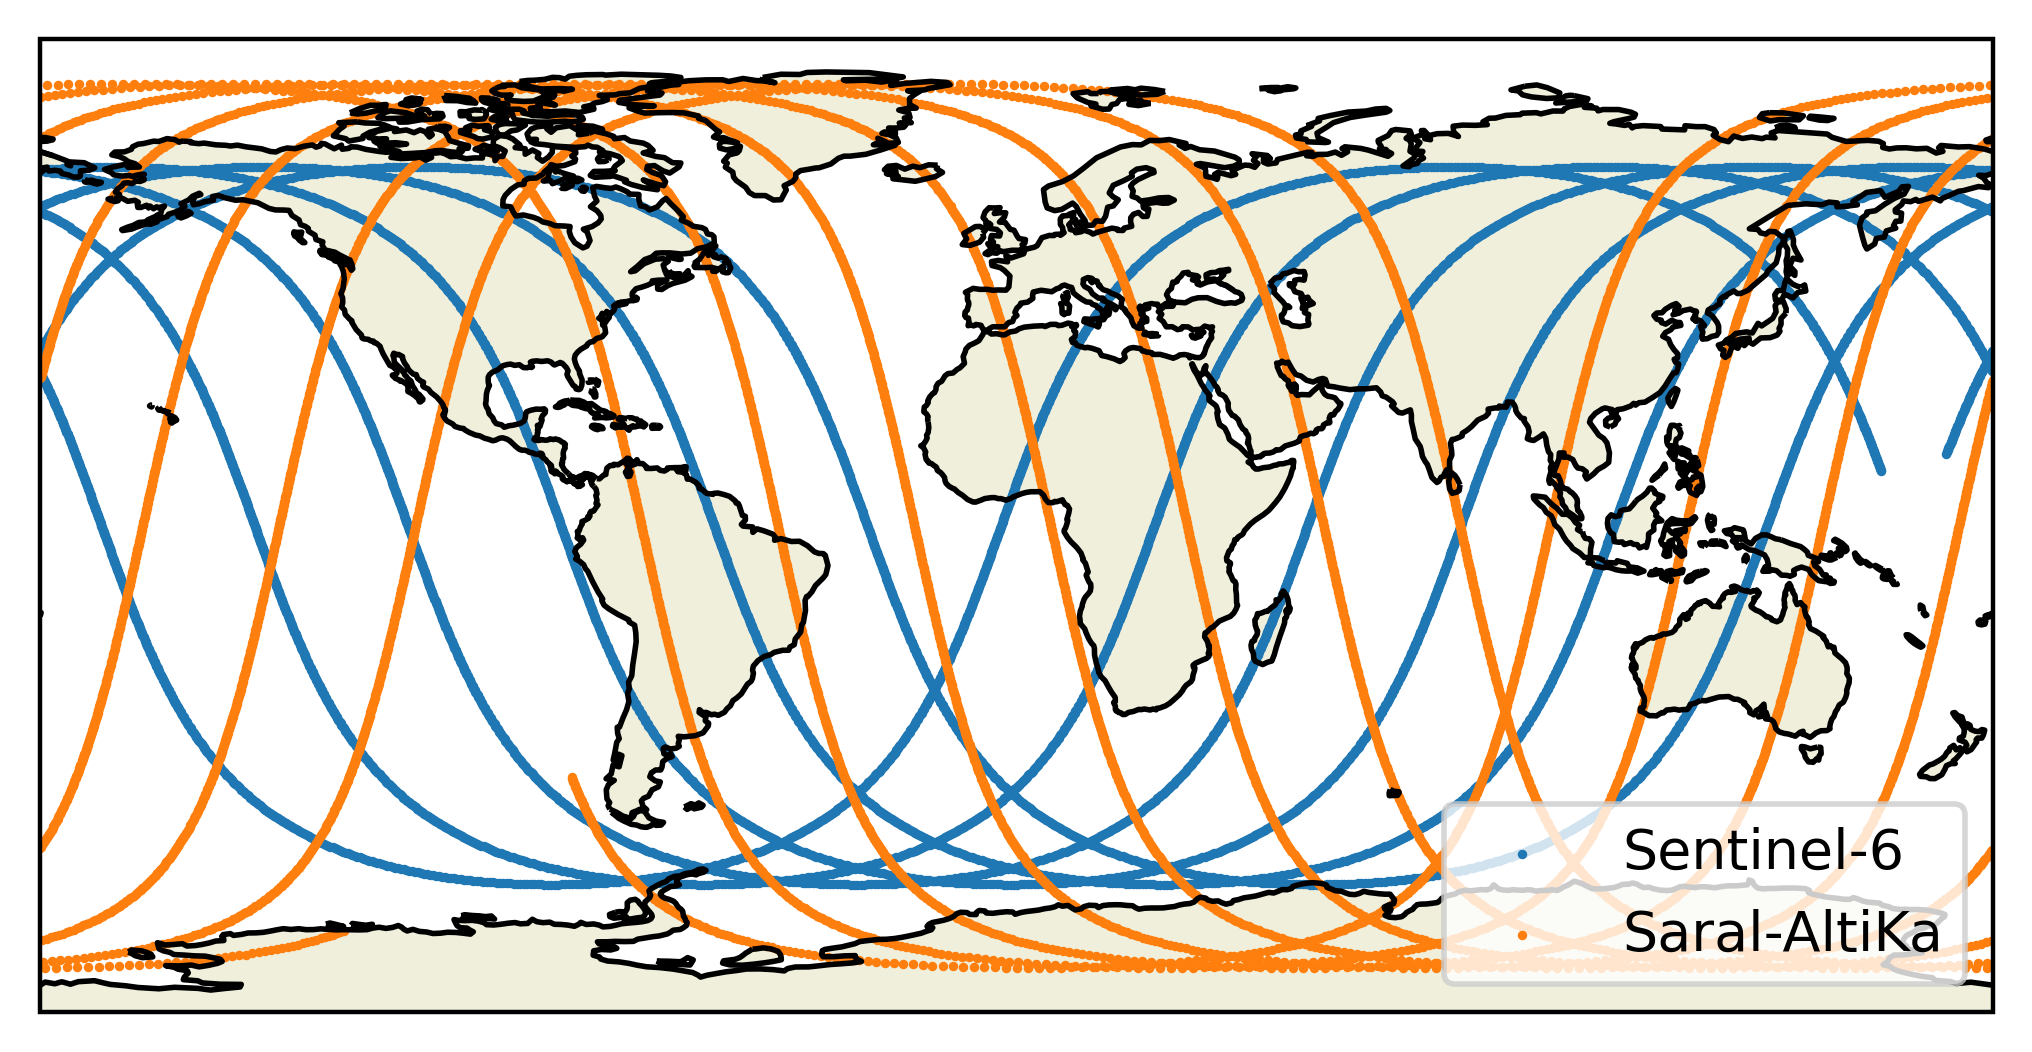

In [3]:
orbit = Orbit.simulate(
    satellites=["S6", "SA"],
    start_date=np.datetime64("2020-02-01T00:00:00"),
    end_date=np.datetime64("2020-02-01T12:00:00"),
    propagation_sampling_interval=np.array(20, dtype="timedelta64[s]"),
    interpolation_sampling_interval=np.array(5, dtype="timedelta64[s]"),
    reference_date=np.datetime64("2000-01-01T00:00:00")
)
print(orbit)
plots = orbit.plot()

In [4]:
print(orbit)


Orbit object for satellites ['S6', 'SA'].
Start date: 2020-02-01T00:00:00
End date: 2020-02-01T12:00:00
Propagation sampling interval: 20 seconds
Interpolation sampling interval: 5 seconds
Reference date used to represent time in seconds since: 2000-01-01T00:00:00
Number of simulated times: 8641


In [5]:
print(orbit.orbits)

<xarray.Dataset> Size: 415kB
Dimensions:         (time: 8641, satellites: 2)
Coordinates:
  * time            (time) float64 69kB 6.338e+08 6.338e+08 ... 6.339e+08
  * satellites      (satellites) <U2 16B 'S6' 'SA'
Data variables:
    reference_date  datetime64[s] 8B 2000-01-01
    time_datetime   (time) datetime64[s] 69kB 2020-02-01 ... 2020-02-01T12:00:00
    lat             (time, satellites) float64 138kB 13.25 -74.64 ... -46.37
    lon             (time, satellites) float64 138kB 171.5 -124.0 ... -81.99
Attributes:
    satellites:                       ['S6', 'SA']
    start_date:                       633830400.0
    end_date:                         633873600.0
    propagation_sampling_interval:    20
    interpolation_sampling_interval:  5


In [6]:
orbit.orbits["time_datetime"]

<xarray.DataArray 'time_datetime' (time: 8641)> Size: 69kB
array(['2020-02-01T00:00:00', '2020-02-01T00:00:05',
       '2020-02-01T00:00:10', ..., '2020-02-01T11:59:50',
       '2020-02-01T11:59:55', '2020-02-01T12:00:00'],
      shape=(8641,), dtype='datetime64[s]')
Coordinates:
  * time     (time) float64 69kB 6.338e+08 6.338e+08 ... 6.339e+08 6.339e+08

In [ ]:
orbit.to_netcdf("./test_export/")

loaded_orbit = Orbit.from_netcdf("./test_export/2020-02-01_2020-02-01_psi20.0_isi5.0_orbit_S6_SA.nc")


PermissionError: [Errno 13] Permission denied: 'c:\\Users\\xl3\\Documents\\projects\\orbitx\\examples\\test_export\\2020-02-01_2020-02-01_psi20.0_isi5.0_orbit_S6_SA.nc'

In [19]:
print(loaded_orbit.orbits["time"])
print()
print(orbit.orbits["time"])

<xarray.DataArray 'time' (time: 8641)> Size: 69kB
array(['2020-02-01T00:00:00.000000000', '2020-02-01T00:00:05.000000000',
       '2020-02-01T00:00:10.000000000', ..., '2020-02-01T11:59:50.000000000',
       '2020-02-01T11:59:55.000000000', '2020-02-01T12:00:00.000000000'],
      shape=(8641,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 69kB 2020-02-01 ... 2020-02-01T12:00:00

<xarray.DataArray 'time' (time: 8641)> Size: 69kB
array([6.338304e+08, 6.338304e+08, 6.338304e+08, ..., 6.338736e+08,
       6.338736e+08, 6.338736e+08], shape=(8641,))
Coordinates:
  * time     (time) float64 69kB 6.338e+08 6.338e+08 ... 6.339e+08 6.339e+08
Attributes:
    units:    seconds since 2000-01-01T00:00:00


In [1]:
from orbitx import Matchups
import numpy as np
matchups = Matchups.find_matchups(
    satellites=["CS2", "J3"],
    start_date=np.datetime64("2012-01-01T00:00:00"),
    end_date=np.datetime64("2012-01-01T12:00:00"),
    propagation_sampling_interval = np.array(60, dtype="timedelta64[s]"),
    interpolation_sampling_interval = np.array(5, dtype="timedelta64[s]"),
    space_diff_threshold = 290,
    time_diff_threshold = np.array(900, dtype="timedelta64[s]"),
    check_before = True,
    check_after = True,
    has_land_ocean_mask = True,
    reference_date=np.datetime64("2000-01-01T00:00:00")
)

C:\Users\xl3\Documents\projects\orbitx\orbitx\data\land_mask\ne_50m_land.shp


C:\Users\xl3\Documents\projects\orbitx\orbitx\tle.py:142: UserWarning: The oldest TLE file is more recent than the start time requested.
 Oldest TLE file: 2016-01-17T20:22:02.081280
 Start time requested: 2011-12-31T23:45:00
  warnings.warn(


In [6]:
print(matchups)


Matchup object with following attributes:
Satellites considered: ['CS2', 'J3']
Date from which matchups are looked for: 2012-01-01T00:00:00
Date until which matchups are looked for: 2012-01-01T12:00:00
Maximum time difference between members of a matchup: 900 seconds (seconds)
Maximum distance between members of a matchup: 290.0 (km)
Are matchups in which on of the satellites appears before the start date considered? True
Are matchups in which on of the satellites appears after the end date considered? True
Has this matchup a land/ocean mask? True
Number of matchups found: 53



In [20]:
print(matchups.matchups)

<xarray.Dataset> Size: 5kB
Dimensions:         (time: 53)
Coordinates:
  * time            (time) float64 424B 3.787e+08 3.787e+08 ... 3.787e+08
Data variables: (12/13)
    reference_date  datetime64[s] 8B 2000-01-01
    time_datetime   (time) datetime64[s] 424B 2012-01-01T09:55:15 ... 2012-01...
    lat1            (time) float64 424B 66.73 -64.78 67.03 ... 66.43 -64.48
    lon1            (time) float64 424B -173.9 -5.807 -174.0 ... -173.8 -5.725
    lat2            (time) float64 424B 66.05 -65.99 66.05 ... 66.02 -66.02
    lon2            (time) float64 424B -168.1 -0.4905 -168.1 ... -167.5 -1.118
    ...              ...
    time2           (time) float64 424B 3.787e+08 3.787e+08 ... 3.787e+08
    time_datetime2  (time) datetime64[s] 424B 2012-01-01T09:45:15 ... 2012-01...
    delay2          (time) timedelta64[s] 424B 0 days 00:10:00 ... 00:03:05
    land_mask1      (time) <U1 212B 'O' 'L' 'O' 'L' 'O' ... 'L' 'O' 'L' 'O' 'L'
    land_mask2      (time) <U1 212B 'O' 'L' 'O' 'L' 'O'

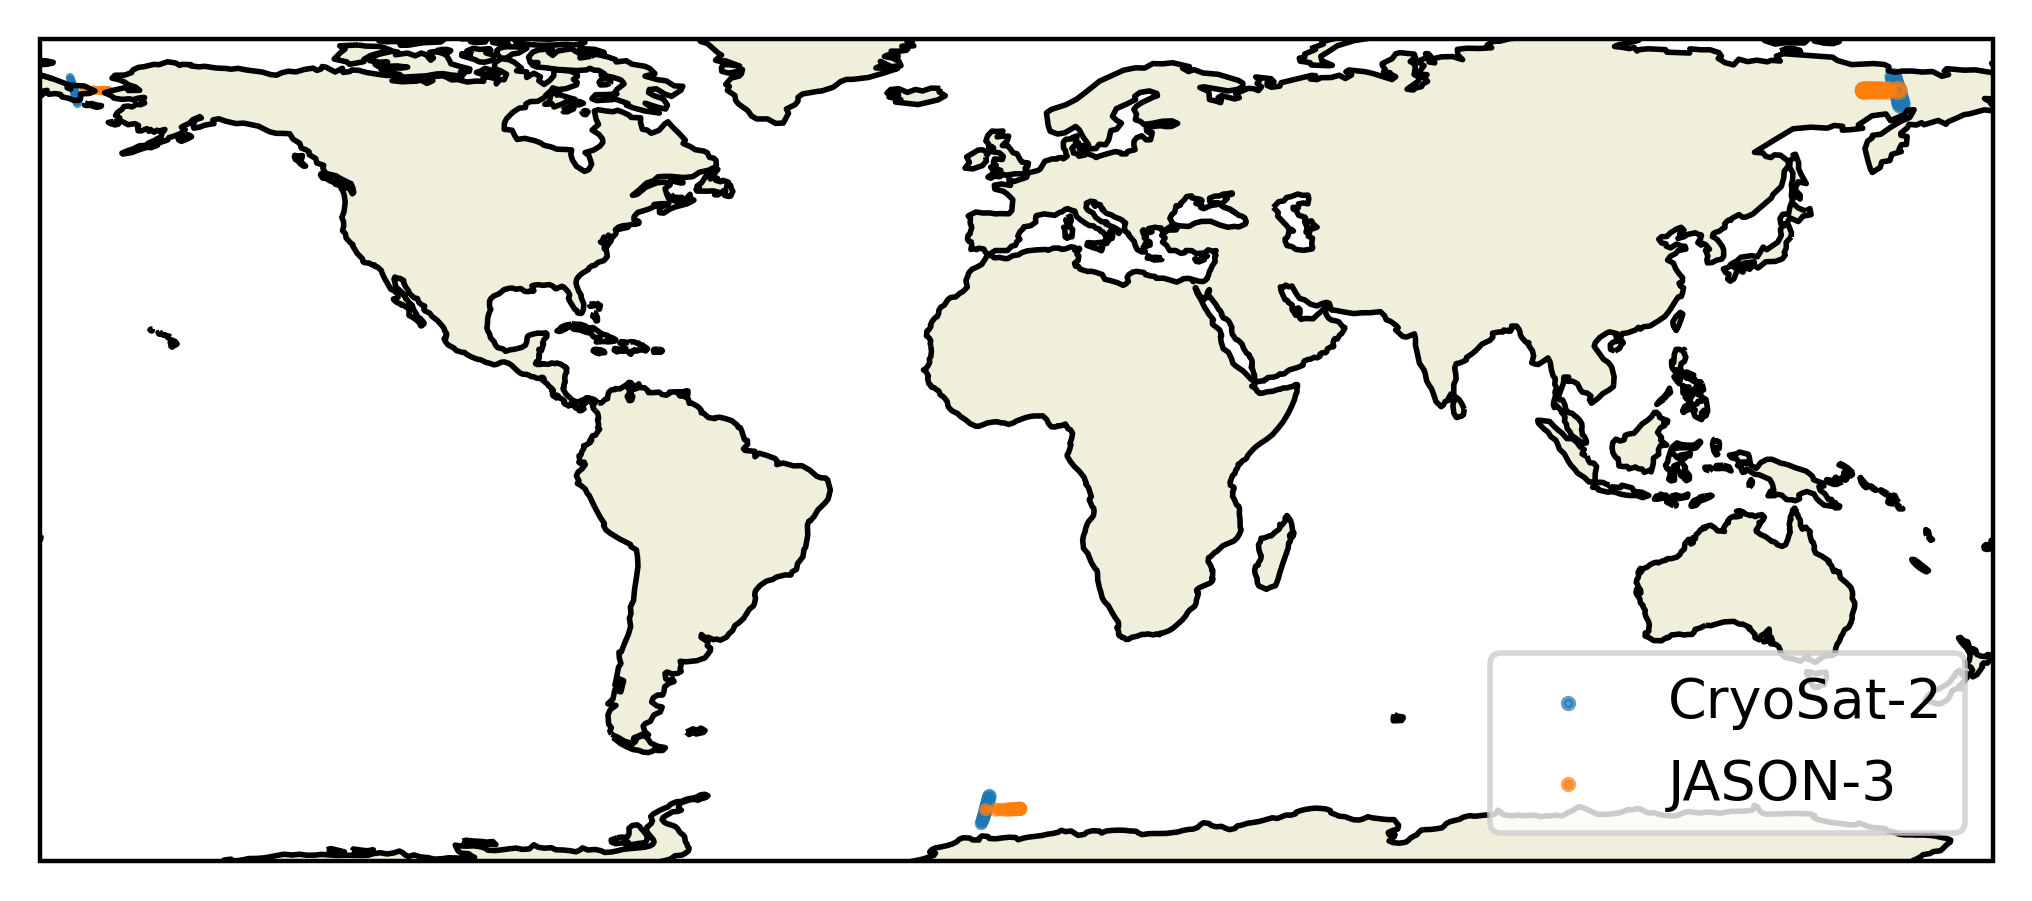

In [8]:
fig = matchups.plot()
fig.savefig("./test_export/matchup_plot.png")

In [9]:
matchups.to_netcdf("./test_export/")

In [1]:
from orbitx import Matchups
loaded_matchup = Matchups.from_netcdf("./test_export/2012-01-01_2012-01-01_psi60.0_isi5.0_matchups_CS2_J3_c2c290.0_tdt900.0.nc")

ImportError: cannot import name 'TLEInfo' from 'orbitx.tle' (C:\Users\xl3\Documents\projects\orbitx\orbitx\tle.py)

In [11]:
print(matchups == loaded_matchup)

True
